# Audio Preprocessing and Visualization

## Objective
This notebook demonstrates audio preprocessing techniques and visualizes different audio representations before and after preprocessing.

### Dataset
Google Speech Commands Dataset (Mini)

### Operations
- Load audio
- Resample
- Normalize
- Trim silence
- Waveform visualization
- Mel Spectrogram
- MFCC Heatmap
- FFT Spectrum

In [1]:
!pip -q install librosa soundfile

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [3]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip

!unzip -q mini_speech_commands.zip

In [4]:
audio_path = "mini_speech_commands/yes/0ab3b47d_nohash_0.wav"

audio, sr = librosa.load(audio_path, sr=None)

print("Sampling Rate:", sr)
print("Audio Length:", len(audio))

Sampling Rate: 16000
Audio Length: 16000


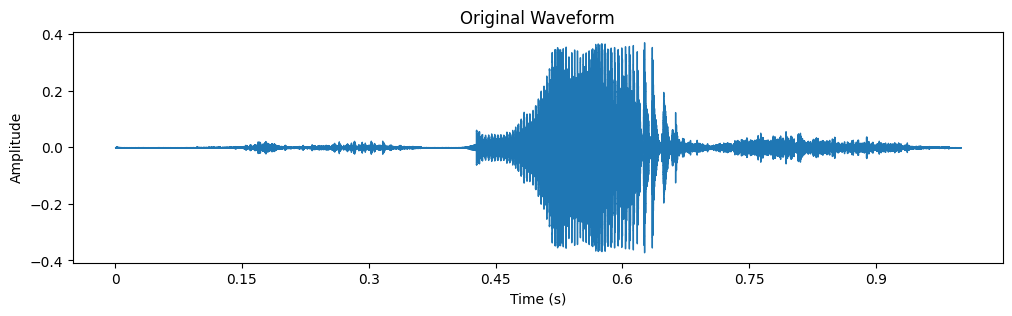

In [5]:
plt.figure(figsize=(12,3))
librosa.display.waveshow(audio, sr=sr)
plt.title("Original Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [6]:
target_sr = 16000

audio_resampled = librosa.resample(
    audio,
    orig_sr=sr,
    target_sr=target_sr
)

In [7]:
audio_normalized = librosa.util.normalize(audio_resampled)

In [8]:
audio_trimmed, index = librosa.effects.trim(audio_normalized)

print(index)

[  512 16000]


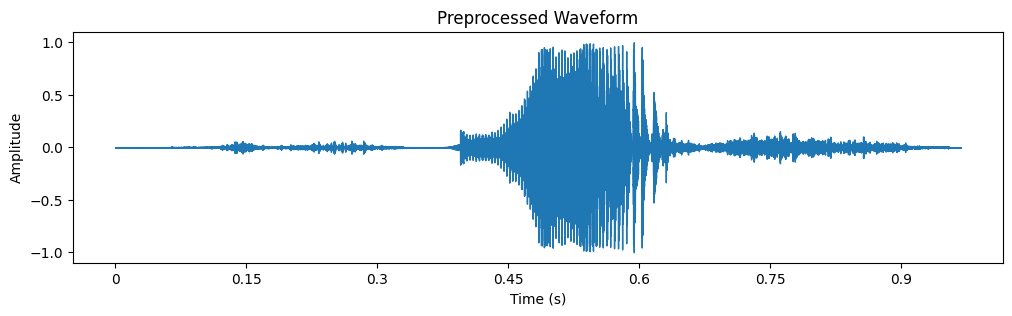

In [9]:
plt.figure(figsize=(12,3))
librosa.display.waveshow(audio_trimmed, sr=target_sr)
plt.title("Preprocessed Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

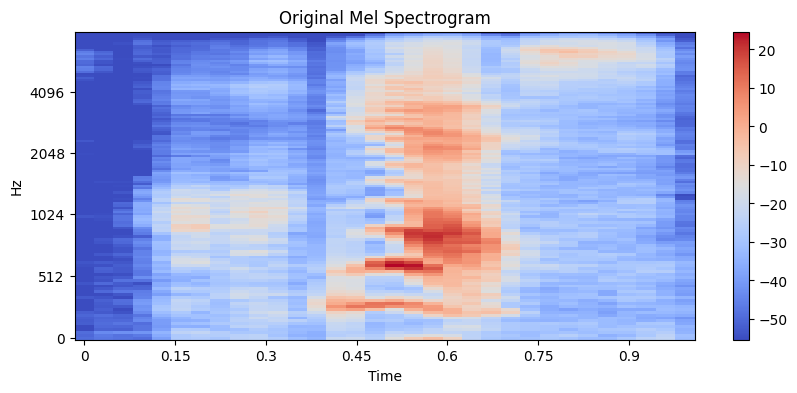

In [10]:
mel_original = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_db = librosa.power_to_db(mel_original)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.title("Original Mel Spectrogram")
plt.show()

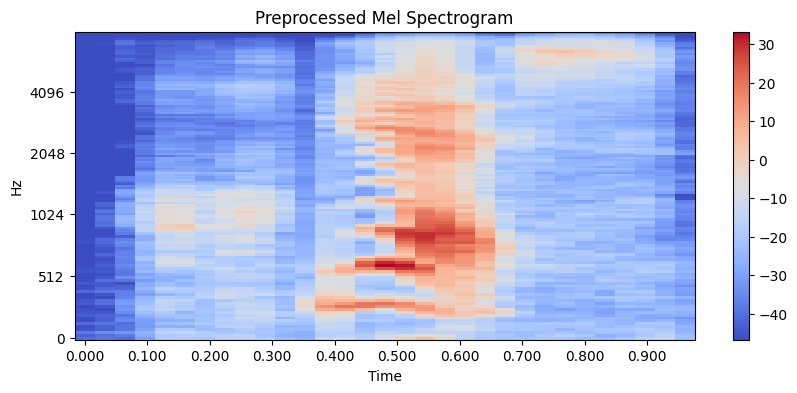

In [11]:
mel_processed = librosa.feature.melspectrogram(
    y=audio_trimmed,
    sr=target_sr
)

mel_db2 = librosa.power_to_db(mel_processed)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db2,
    sr=target_sr,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.title("Preprocessed Mel Spectrogram")
plt.show()

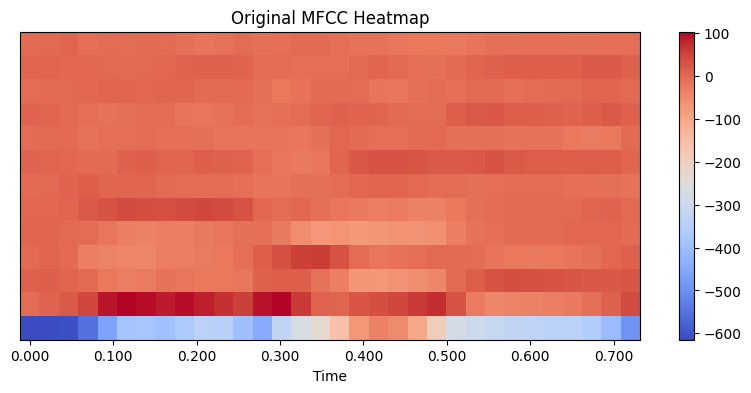

In [12]:
mfcc_original = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mfcc_original,
    x_axis='time'
)
plt.colorbar()
plt.title("Original MFCC Heatmap")
plt.show()

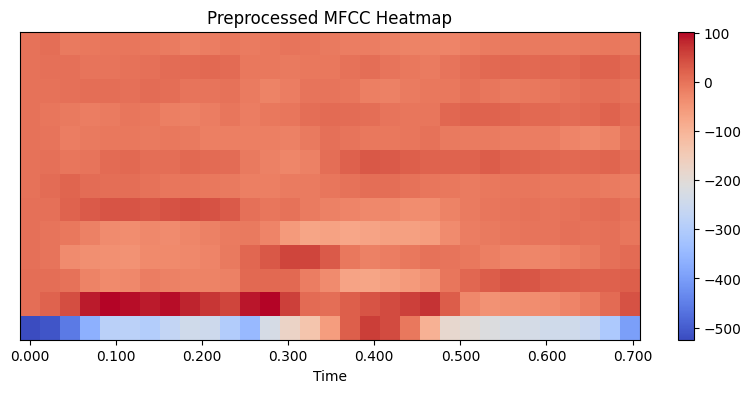

In [13]:
mfcc_processed = librosa.feature.mfcc(
    y=audio_trimmed,
    sr=target_sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mfcc_processed,
    x_axis='time'
)
plt.colorbar()
plt.title("Preprocessed MFCC Heatmap")
plt.show()

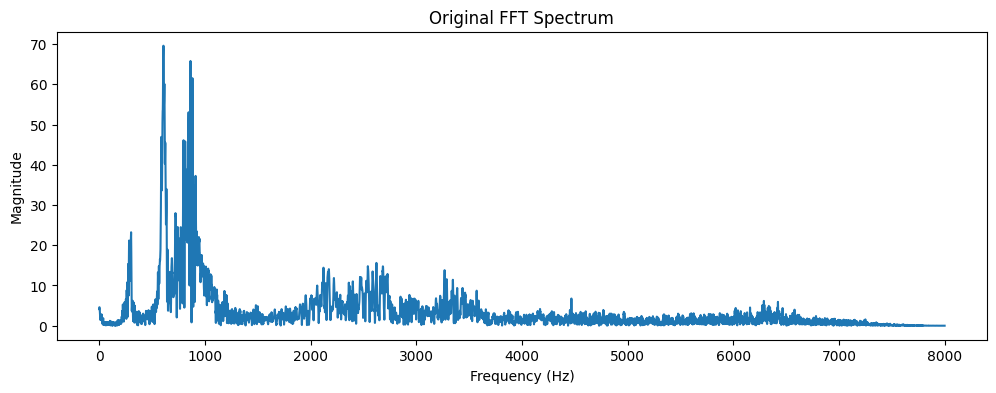

In [14]:
fft = np.fft.fft(audio)

freq = np.fft.fftfreq(len(audio),1/sr)

plt.figure(figsize=(12,4))
plt.plot(freq[:len(freq)//2],
         np.abs(fft[:len(freq)//2]))
plt.title("Original FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

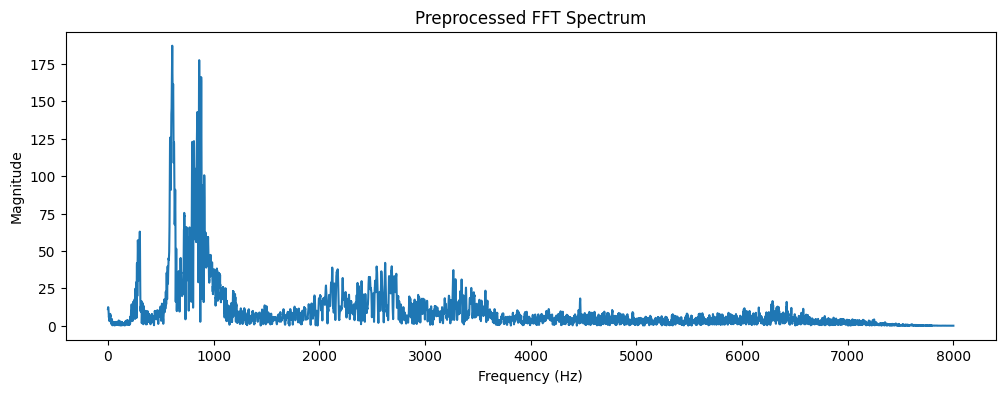

In [15]:
fft2 = np.fft.fft(audio_trimmed)

freq2 = np.fft.fftfreq(len(audio_trimmed),1/target_sr)

plt.figure(figsize=(12,4))
plt.plot(freq2[:len(freq2)//2],
         np.abs(fft2[:len(freq2)//2]))
plt.title("Preprocessed FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

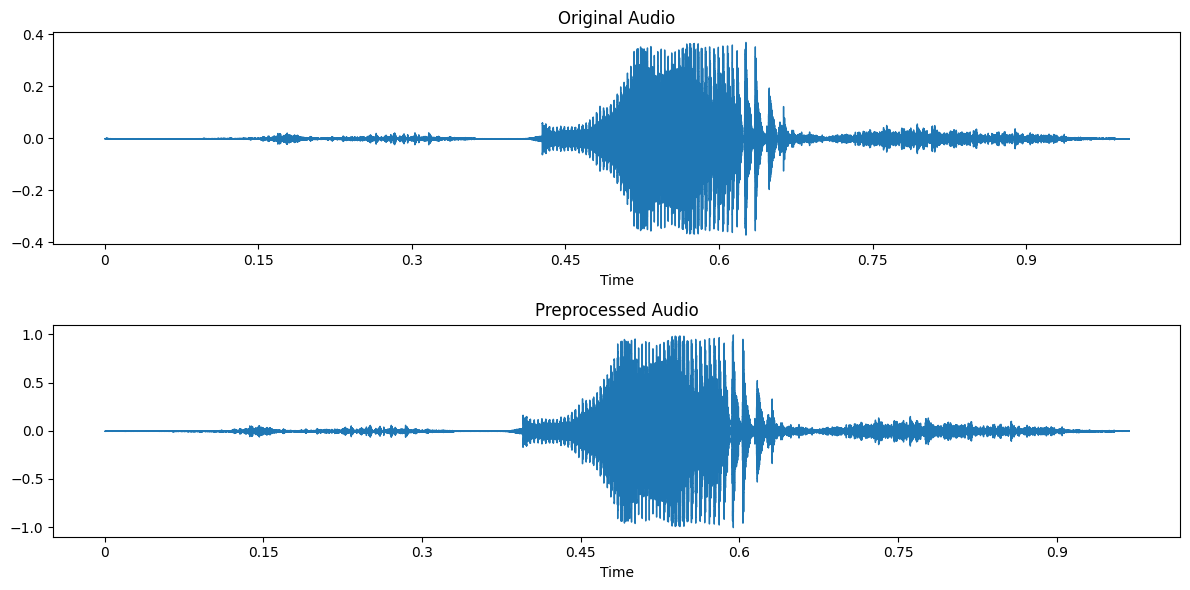

In [16]:
fig, ax = plt.subplots(2,1,figsize=(12,6))

librosa.display.waveshow(audio,sr=sr,ax=ax[0])
ax[0].set_title("Original Audio")

librosa.display.waveshow(audio_trimmed,sr=target_sr,ax=ax[1])
ax[1].set_title("Preprocessed Audio")

plt.tight_layout()
plt.show()